In [ ]:
#Cargar librerias necesarias
import os
import pandas
import random
import numpy as np

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split, StratifiedKFold

import matplotlib.pyplot as plt
from IPython.display import Image

from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score

In [3]:
url_dataset = "https://raw.githubusercontent.com/Xachap/cell-network-example/main/cells.csv"

In [4]:
# Función para definir la estructura
def baseline_model():
	# Creamos el modelo
	# Capas a definir:
	#		Entrada: 4 neuronas
	#		Capa oculta: 4 neuronas
	# 	Capa de salida: 3 neuronas (una por cada clase)
	model = Sequential()

  # Indicamos que la primera capa oculta se alimenta de una capa de entrada de 4 variables (input_dim)
	# y a su vez está formada por 4 neuronas. La función de activación es relu
	model.add(Dense(4, input_dim=4, activation='relu'))

  # La capa de salida está formada por 3 neuronas, una por cada clase
	model.add(Dense(3, activation='sigmoid'))

	# Compilamos, mostramos y devolvemos el modelo
	model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
	print(model.summary())

	return model

In [5]:
def plot_history(history):
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Error')
  plt.plot(history.epoch, np.array(history.history['loss']),
           label='Error (loss) en entrenamiento')
  plt.plot(history.epoch, np.array(history.history['val_loss']), label='Error (loss) en validación')
  plt.legend()
  plt.ylim([0, max(1,max(np.array(history.history['loss'])))])
  plt.ylim([0, max(1,max(np.array(history.history['val_loss'])))])

In [6]:
# Las clases aparecen sin codificar
# Es necesario asignarle un número entero a cada una
classes = {
  "Normal": 0,
  "Benigno": 1,
  "Maligno": 2
}

Preparación del Dataset

In [7]:
# Cargamos el conjunto de datos (csv) a través de la URL
dataframe = pandas.read_csv(url_dataset, header = None)

# Mostramos el conjunto de datos
print("Estructura del dataset:\n")
dataset = dataframe.values
print(dataset)

Estructura del dataset:

[[5.1 3.5 1.4 0.2 'Normal']
 [4.9 3.0 1.4 0.2 'Normal']
 [4.7 3.2 1.3 0.2 'Normal']
 [4.6 3.1 1.5 0.2 'Normal']
 [5.0 3.6 1.4 0.2 'Normal']
 [5.4 3.9 1.7 0.4 'Normal']
 [4.6 3.4 1.4 0.3 'Normal']
 [5.0 3.4 1.5 0.2 'Normal']
 [4.4 2.9 1.4 0.2 'Normal']
 [4.9 3.1 1.5 0.1 'Normal']
 [5.4 3.7 1.5 0.2 'Normal']
 [4.8 3.4 1.6 0.2 'Normal']
 [4.8 3.0 1.4 0.1 'Normal']
 [4.3 3.0 1.1 0.1 'Normal']
 [5.8 4.0 1.2 0.2 'Normal']
 [5.7 4.4 1.5 0.4 'Normal']
 [5.4 3.9 1.3 0.4 'Normal']
 [5.1 3.5 1.4 0.3 'Normal']
 [5.7 3.8 1.7 0.3 'Normal']
 [5.1 3.8 1.5 0.3 'Normal']
 [5.4 3.4 1.7 0.2 'Normal']
 [5.1 3.7 1.5 0.4 'Normal']
 [4.6 3.6 1.0 0.2 'Normal']
 [5.1 3.3 1.7 0.5 'Normal']
 [4.8 3.4 1.9 0.2 'Normal']
 [5.0 3.0 1.6 0.2 'Normal']
 [5.0 3.4 1.6 0.4 'Normal']
 [5.2 3.5 1.5 0.2 'Normal']
 [5.2 3.4 1.4 0.2 'Normal']
 [4.7 3.2 1.6 0.2 'Normal']
 [4.8 3.1 1.6 0.2 'Normal']
 [5.4 3.4 1.5 0.4 'Normal']
 [5.2 4.1 1.5 0.1 'Normal']
 [5.5 4.2 1.4 0.2 'Normal']
 [4.9 3.1 1.5 0.1 'Norm

In [8]:
# Dividimos el conjunto de datos en variables de entrada (X) y salida (Y)
X = dataset[:,0:4].astype(float)
Y = dataset[:,4]
print(f"Variables de entrada: ", X)
print(f"Variables de salida: ", Y)

Variables de entrada:  [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.

In [9]:
# Dividimos el conjunto de datos en dos, una parte para entrenamiento y otra para test
# Importante indicar en stratify la columna donde se encuentran las clases, para que cada
# división tenga los mismos porcentajes en cuanto a balanceo se refiere.
SEED = 42

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, stratify = Y, random_state = SEED, shuffle = True)

print(f"Datos de entrada para el entrenamiento:", X_train)
print(f"Datos de entrada para el test: ", X_test)
print(f"Salidas para el entrenamiento:", y_train)
print(f"Salidas para el test:", y_test)


Datos de entrada para el entrenamiento: [[6.2 3.4 5.4 2.3]
 [7.7 2.6 6.9 2.3]
 [5.6 2.5 3.9 1.1]
 [5.  3.5 1.6 0.6]
 [5.9 3.  5.1 1.8]
 [4.8 3.  1.4 0.3]
 [5.2 2.7 3.9 1.4]
 [5.7 2.9 4.2 1.3]
 [6.6 2.9 4.6 1.3]
 [4.7 3.2 1.3 0.2]
 [5.4 3.7 1.5 0.2]
 [6.4 3.2 4.5 1.5]
 [6.6 3.  4.4 1.4]
 [6.4 2.8 5.6 2.1]
 [7.4 2.8 6.1 1.9]
 [5.  3.  1.6 0.2]
 [6.8 2.8 4.8 1.4]
 [5.7 2.6 3.5 1. ]
 [5.1 3.8 1.9 0.4]
 [6.9 3.2 5.7 2.3]
 [5.5 2.4 3.7 1. ]
 [5.1 3.3 1.7 0.5]
 [5.4 3.9 1.7 0.4]
 [4.6 3.6 1.  0.2]
 [6.7 3.  5.2 2.3]
 [6.3 3.3 4.7 1.6]
 [6.1 2.8 4.  1.3]
 [5.6 3.  4.5 1.5]
 [7.1 3.  5.9 2.1]
 [6.9 3.1 5.4 2.1]
 [6.7 3.1 4.4 1.4]
 [5.8 2.7 4.1 1. ]
 [7.7 3.8 6.7 2.2]
 [5.8 2.8 5.1 2.4]
 [6.  2.2 4.  1. ]
 [5.7 3.  4.2 1.2]
 [6.4 3.2 5.3 2.3]
 [5.1 3.8 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [7.  3.2 4.7 1.4]
 [5.2 3.4 1.4 0.2]
 [6.2 2.9 4.3 1.3]
 [5.1 3.8 1.5 0.3]
 [6.7 3.1 4.7 1.5]
 [5.1 3.5 1.4 0.2]
 [6.8 3.  5.5 2.1]
 [6.4 2.9 4.3 1.3]
 [5.  3.2 1.2 0.2]
 [5.6 2.8 4.9 2. ]
 [4.3 3.  1.1 0.1]
 [6.4 2.8 

In [10]:
# Sustituimos los nombres de las clases por el entero asignado,
# tanto para el conjunto de entrenamiento como para el de test
y_train = [classes[elem] for elem in y_train]
y_test = [classes[elem] for elem in y_test]

# Traducimos cada clase a un vector
# Esto es necesario para trabajar con redes neuronales
# en Keras.
# Clase "Normal" = 0 = (1,0,0)
# Clase "Benigno" = 1 = (0,1,0)
# Clase "Maligno" = 2 = (0,0,1)
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)

print(train_labels)
print(test_labels)

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1.

c:\Users\Ra7x\Desktop\Big Data e IA\IA\Práctica Cell Net Evaluación de Modelos\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3333 - loss: 2.3180 - val_accuracy: 0.3333 - val_loss: 2.0367
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3333 - loss: 1.8697 - val_accuracy: 0.3333 - val_loss: 1.6491
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3333 - loss: 1.5094 - val_accuracy: 0.3333 - val_loss: 1.3499
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3333 - loss: 1.2478 - val_accuracy: 0.3333 - val_loss: 1.1441
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3524 - loss: 1.0764 - val_accuracy: 0.4000 - val_loss: 1.0096
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.9628 - val_accuracy: 0.6667 - val_loss: 0.9121
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.8745 - val_accuracy: 0.6667 - val_loss: 0.8274
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.8017 - val_accuracy: 0.66

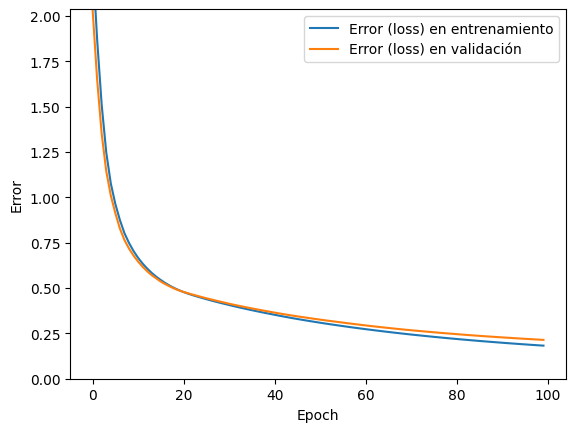

In [11]:
# Aseguramos la reproducibilidad del modelo con la semilla fijada anteriormente
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Creamos una instancia del modelo
network = baseline_model()

# Entrenamos el modelo
history = network.fit(X_train, train_labels, epochs=100, batch_size=5, validation_data=(X_test, test_labels), shuffle=True)

# Mostramos la gráfica de entrenamiento
plot_history(history)
print("Máximo error:",max(np.array(history.history['loss'])))
print("Mínimo error:",min(np.array(history.history['loss'])))

In [12]:
# Calculamos la tasa de acierto sobre el conjunto de test
test_loss, test_acc = network.evaluate(X_test, test_labels)
print('Test Accuracy: ', test_acc, '\nTest Loss: ', test_loss)

# Devolvemos directamente la clase con el valor de predicción
# más alto
y_pred = np.argmax(network.predict(X_test), axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9556 - loss: 0.2140 
Test Accuracy:  0.9555555582046509 
Test Loss:  0.21403567492961884
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


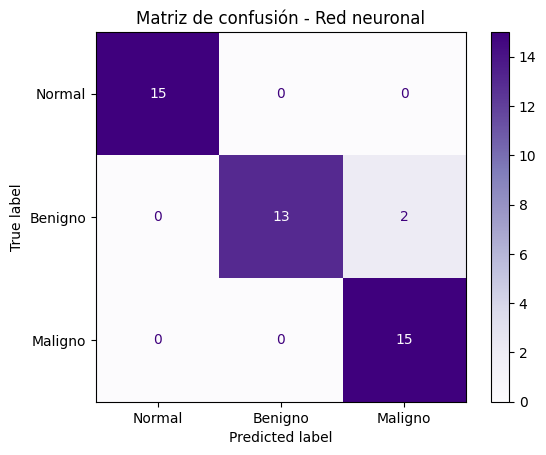

In [13]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Purples")
plt.title("Matriz de confusión - Red neuronal")
plt.show()

In [14]:
# Mostramos las métricas asociadas a la matriz de confusión
print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        15
     Benigno       1.00      0.87      0.93        15
     Maligno       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



### **Segunda parte: validación** (Parte de código - 3ptos)
Revisando la celda en la que se entrena el modelo, vemos que hay un error. **¿Qué problema se está produciendo?**

Soluciónalo con una nueva partición de validación. Hay dos opciones:
- Aplicar validación simple: es la opción más sencilla y sólo tendremos que volver a dividir el conjunto de entrenamiento en dos. Recuerda traducir las etiquetas de las clases para el conjunto de validación, tal y como se hace ya en la libreta para *training* y *test*. Realizar esta modificación sólo aporta **0,75/3** sobre la calificación total del apartado.

- Aplicar validación cruzada: esta opción es la realmente óptima para nuestro problema, debido, entre otras cuestiones, a que tenemos un conjunto de datos muy pequeño. Sin embargo, es la más compleja, y por lo tanto implementar esta modificación correctamente hace que optemos a la máxima nota para este apartado **(2/2)**. Hay dos formas de implementarla en este caso:
  * Con StratifiedKFold (de Scikit): este método puede parecer la solución más directa, y de hecho lo es si trabajamos con modelos de Scikit, pero al usar un modelo hecho con Keras tendremos que realizar algunas conversiones de datos. Esta forma puede no ser demasiado intuitiva cuando comenzamos a trabajar con modelos de Machine Learning, pero puede realizarse. Para más información sobre los formatos de etiquetas, consulta el [Anexo](#anexo) de esta libreta.

  * Creando nuestro propio algoritmo: puedes ver los diferentes pasos que lo componen en el archivo "implementacion_cv_keras.pdf" que aparece en el Aula Virtual (en Programación de Inteligencia Artificial).

**Importante**: en el caso de implementar la validación cruzada, hay que entrenar al final del proceso un nuevo modelo (modelo final) usando todos los datos de entrenamiento, por lo que no usaremos nada relacionado con el hiperparámetro "validation_data". Este modelo será el que pondremos a prueba con el conjuto de *test* (apartado de validación). Para mostrar la gráfica en este punto, tenemos que tener en cuenta que sólo tenemos disponibles los resultados del entrenamiento, así que tendremos que modificar su función correspondiente para que se pueda ejecutar sin problema alguno.

#TO DO
El error que se está produciendo es que que al modelo se le están pasando los datos de test. Estos datos nunca debería recibirlos el modelo ya que son los datos que debería emplear para comparar el resultado de sue entrenamiento. En su lugar debería recibir los datos de entrenamiento

In [15]:
# 1. Preparación de los datos
train_labels_encoded = np.argmax(train_labels, axis=1)

k = 5  # Número de folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Listas para almacenar los resultados de cada fold
acc_per_fold = []
loss_per_fold = []

# 2. Bucle de Validación Cruzada
fold_no = 1
for train_index, val_index in skf.split(X_train, train_labels_encoded):

    # Divido los datos según los datos  de validación cruzada
    x_train_fold, x_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = train_labels[train_index], train_labels[val_index]

    print(f'Entrenando Fold {fold_no}...')

    # Creo una instancia nueva del modelo en cada iteración
    model = baseline_model()

    # Entreno el modelo con los datos de cada fold
    model.fit(x_train_fold, y_train_fold,
              epochs=100,
              batch_size=5,
              verbose=0)

    # Evaluo el fold
    scores = model.evaluate(x_val_fold, y_val_fold, verbose=0)
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1

print(f'\nPrecisión media: {np.mean(acc_per_fold)}% (+/- {np.std(acc_per_fold)})')

Entrenando Fold 1...


c:\Users\Ra7x\Desktop\Big Data e IA\IA\Práctica Cell Net Evaluación de Modelos\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

None

Precisión media: 86.66666746139526% (+/- 11.428570747375488)


Entrenando modelo final con todos los datos de entrenamiento...


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35 (140.00 B)

 Trainable params: 35 (140.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5048 - loss: 0.9684   
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4571 - loss: 0.9111 
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3905 - loss: 0.8610 
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4571 - loss: 0.8180 
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5238 - loss: 0.7884 
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5714 - loss: 0.7678 
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5905 - loss: 0.7526 
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6286 - loss: 0.7392 
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6286 - loss: 0.7272 
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6476 - loss: 0.7159 
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6476 - loss: 0.7000 
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

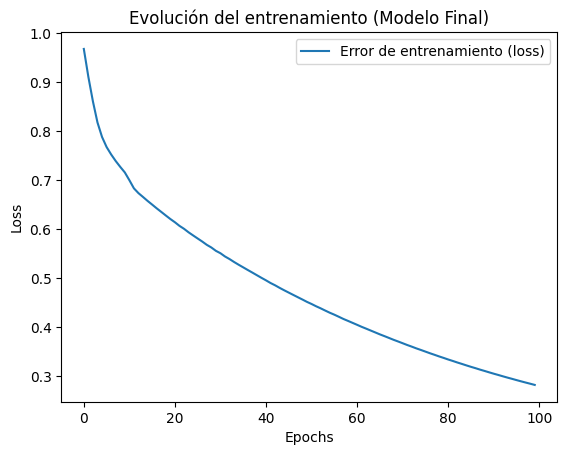

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9778 - loss: 0.2828 

RESULTADO FINAL EN TEST -> Acc: 97.78%, Loss: 0.2828


In [20]:
# --- MODELO FINAL ---
print("Entrenando modelo final con todos los datos de entrenamiento...")

final_network = baseline_model()

# Entrenamiento sin 'validation_data' para usar todo el dataset
history_final = final_network.fit(
    X_train,
    train_labels,
    epochs=100,
    batch_size=5,
    shuffle=True
)

# --- GRÁFICA DE ENTRENAMIENTO ---
def plot_final_history(history):
    plt.plot(history.history['loss'], label='Error de entrenamiento (loss)')
    plt.title('Evolución del entrenamiento (Modelo Final)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_final_history(history_final)

test_loss, test_acc = final_network.evaluate(X_test, test_labels)
print(f'\nRESULTADO FINAL EN TEST -> Acc: {test_acc*100:.2f}%, Loss: {test_loss:.4f}')


In [ ]:
raw_predictions = final_network.predict(X_test)

# Convertir predicciones y etiquetas reales a índices de clase
y_pred = np.argmax(raw_predictions, axis=1)
y_test = np.argmax(test_labels, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accurancy: ", acc)
print(f"Precisión: ", prec)
print(f"F1 Score: ", f1)

print()
print("Classification report: ")
print()
print(classification_report(y_test, y_pred))

# 4. Matriz de Confusión para el análisis de errores
print("\nMATRIZ DE CONFUSIÓN:")
confusionMatrix = confusion_matrix(y_test, y_pred)
print(confusionMatrix)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Accurancy:  0.9777777777777777
Precisión:  0.9791666666666666
F1 Score:  0.9777530589543938

Classification report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


MATRIZ DE CONFUSIÓN:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


### **Tercera parte: investigación de modelos supervisados** (Parte de código - 4ptos)

Define y entrena un modelo de ML (para problemas de clasificación), con el fin de compararlo posteriormente con nuestra red neuronal. Se puede elegir cualquiera de los que incluye scikit, pero será necesario que expliquéis su funcionamiento con vuestras propias palabras.

En principio, los algoritmos disponibles son los siguientes (aunque tendréis que aseguraros de que el algoritmo elegido realmente se puede utilizar en este problema):



Para este caso voy a emplear el algoritmo ***Random Forest Classifier*** ya que pertenece a la familia del Ensamble Learning o Aprendizaje por conjunto. Lo que se traduce en: En lugar de confiar en una sola respuesta, baraja una solución en base a una multitud de respuestas. Algo asi como si una seerie de médicos tienen que determinar si una célula es cancerígena, pero, para ello se les distribuyen diferentes características de la célula, algo así como decirle a un médico "este es el tamaño del núcleo", a otro "esta es la forma de la célula"... Y así sucesivamente. Y entre lo que determinen todos los médicos se toma una decisión

--- Métricas del Modelo ---
Accuracy (Exactitud): 91.11111111111111%
Precision (Precisión): 91.55354449472097%
F1-Score: 91.07142857142857%

--- Representación del modelo--


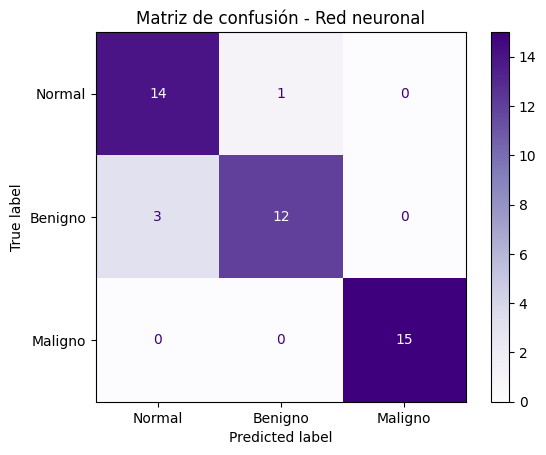


--- Informe Detallado por Clase ---
              precision    recall  f1-score   support

     Benigno       0.82      0.93      0.88        15
     Maligno       0.92      0.80      0.86        15
      Normal       1.00      1.00      1.00        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


MATRIZ DE CONFUSIÓN:
[[14  1  0]
 [ 3 12  0]
 [ 0  0 15]]


: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report


# 1. Definición del modelo
ml_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Entrenamiento del modelo
ml_model.fit(X_train, y_train)

# 3. Predicción y evaluación
y_pred = ml_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"--- Métricas del Modelo ---")
print(f"Accuracy (Exactitud): {acc * 100}%")
print(f"Precision (Precisión): {prec * 100}%")
print(f"F1-Score: {f1 * 100}%")

print("\n--- Representación del modelo--")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Purples")
plt.title("Matriz de confusión - Red neuronal")
plt.show()

print("\n--- Informe Detallado por Clase ---")
print(classification_report(y_test, y_pred))

print("\nMATRIZ DE CONFUSIÓN:")
confusionMatrix = confusion_matrix(y_test, y_pred)
print(confusionMatrix)

### **Cuarta parte: comparativa de modelos** (Parte de código - 3ptos)
Habiendo entrenado los dos modelos, se evaluarán utilizando los recursos creados en el ejercicio de evaluación de modelos. Éstos nos servirán para evaluar de manera individual cada una de las soluciones propuestas, y posteriormente compararlas. Se valorará la claridad, detalle y desarrollo del apartado.

##El Modelo 1 (Validación Cruzada)
Es un modelo casi perfecto. Solo tiene un error: clasificó un caso de Clase 1 como Clase 2.

En este caso estaríamos hablando de un Falso Positivo (de malignidad) en medicina, este "susto", se traduciría como mucho en una señal de alerta, lo que se traduciría en más pruebas donde finalmente se descartaría, lo cual al fin y al cabo no supone ninguna clase de riesgo para la vida del paciente

##El Modelo 2 (Random Forest)
Tiene 4 errores, y aquí es donde podría haber peligro, sin embargo, en este caso el modelo ha sido bastante conservador ya que sus errores no representan ningún peligro directo para el paciente. En la clase normal ha predicho uno de estos tumores como benignos, además, en la clase benigno, ha predicho 3 de estos tumores como normales siendo benignos. Como podemos ver presenta cierto error a la hora de distinguir entre benignos y nomales, sin embargo, cuando se trata de malignos ha tenido un 100% de aciertos lo que representa una excelente cifra y más tratándose de la temática de la que estamos hablado 

##Conclusión
El Modelo 1 es claramente superior por su excepticismo al lado del 2: El Modelo 1 tiene un Recall (sensibilidad) perfecto o casi perfecto en todas las clases. En oncología, es preferible un modelo que peque de precavido (baja precisión, alta sensibilidad) antes que uno que ignore tumores malignos.

### **Quinta parte: documentación** (Parte teórica - 7ptos)

Se creará una pequeña guía sobre el funcionamiento y uso del algoritmo utilizado, preferiblemente en formato *Markdown*, para ser expuesta en un repositorio de GitHub. **Las ideas principales de dicha guía se expondrán posteriormente en una clase**. La forma de dicha sesión está por determinar, pero los contenidos a exponer (que tendrán que estar reflejados en la guía) deben centrarse en:

*   Funcionamiento del algoritmo
*   Consideraciones/detalles a tener en cuenta a la hora de implementarlo (por ejemplo, problemas que puedan surgir).

Guía de Implementación: Random Forest Classifier para Diagnóstico Médico
Este repositorio contiene la implementación de un modelo Random Forest (Bosque Aleatorio) para la clasificación de tumores. El objetivo es proporcionar una herramienta de apoyo al diagnóstico que sea robusta y fácil de interpretar.

1. ¿Cómo funciona el algoritmo?
El Random Forest es un algoritmo de aprendizaje supervisado que utiliza un "ensamble" o de múltiples Árboles de Decisión.

Bootstrapping: El algoritmo crea múltiples subconjuntos de datos al azar a partir del dataset original.

Construcción de Árboles: Entrena un árbol de decisión para cada subconjunto. Sin embargo, en cada división de los nodos, solo considera un número aleatorio de características (features), lo que aumenta la diversidad.

Votación Mayoritaria (Aggregating): Para predecir si un tumor es benigno o maligno, el modelo pide la "opinión" a todos los árboles creados. La clase que recibe más votos es la predicción final.

¿Por qué? Para reducir drásticamente el riesgo de overfitting (sobreajuste) que tienen los árboles individuales, siendo mucho más estable ante datos nuevos.

2. Consideraciones y Detalles de Implementación
A la hora de llevar este código a un entorno real o académico, hay que tener en cuenta ciertos críticos:

A. Desbalanceo de Clases (El problema crítico)
En diagnósticos médicos, a menudo hay muchas más muestras de tumores benignos que malignos.

Problema: El modelo puede volverse "perezoso" y aprender a decir siempre "benigno" para obtener una precisión (Accuracy) alta, fallando en detectar los casos positivos reales.

Solución: Revisar el parámetro class_weight='balanced' en el constructor de Scikit-Learn o monitorizar el Recall por encima del Accuracy.

B. El sesgo de la Matriz de Confusión
No todos los errores valen lo mismo. En este proyecto:

Falso Positivo: Decir que es maligno cuando es benigno (causa estrés y pruebas extra).

Falso Negativo: Decir que es benigno cuando es maligno (Riesgo vital).

Detalle técnico: En medicina, solemos ajustar el modelo para maximizar el Recall de la clase maligna, incluso si eso baja un poco la precisión global.

C. Importancia de las Variables (Feature Importance)
Una gran ventaja de RandomForestClassifier es que, tras el entrenamiento, podemos consultar ml_model.feature_importances_.

Esto nos permite explicar a los médicos qué características (como el radio, la textura o el perímetro del tumor) están influyendo más en la decisión del algoritmo, permitiendo un modelo interpretable.

3. Estructura del Código
Python

# Configuración base recomendada
ml_model = RandomForestClassifier(
    n_estimators=100,    # Número de árboles. Más es más robusto, pero más lento.
    random_state=42,     # Asegura que los resultados sean reproducibles.
    max_depth=None       # Controla la profundidad para evitar sobreajuste.
)
Ideas para tu exposición en clase
Si quieres destacar, cuando hables de estos contenidos menciona lo siguiente:

Analogía: "Es como consultar a 100 médicos diferentes y tomar la decisión que la mayoría sugiera".

Debate: Pregunta a la clase: ¿Qué preferiríais en este modelo, un 99% de Accuracy o un 100% de Recall en tumores malignos aunque fallemos más en los benignos? (Esto abre el debate sobre la ética en IA médica).